In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
from setup import *
from plts_funcs import *

stiles = ['-', '--', '-.', ':', ""]
colors = ["blue", "orange", "lightgreen", "red", "purple"]

In [ ]:
set_style()
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec

## corrugation modes model

$\omega = m \Omega_{\phi} - j^{1/2} \Omega_\theta$

calcolate a $r_{ivr}$, raggio di risonanza verticale, definito proprio come il valore per cui quell'uguagliaanza è soddisfatta fissata la frequenza.

In [ ]:
def c_fq(m, j, a, rivr, M=M_BH):
    rivr = np.asarray(rivr)
    a = np.asarray(a)
    M = np.asarray(M)
    j = np.asarray(j)
    m = np.asarray(m)

    return m * nu_phi(rivr, a, M) - np.sqrt(j) * nu_theta(rivr, a, M)

### 1 - no insight fisiche, solo trovare rivr con r_in fissato a isco.

si può fare perché la frequenza sopra è fissata indipendentemente da rin

M fissata

In [ ]:
params = {
    "m": (0, 3, 4),
    "j": (0, 3, 4),
    "a": (-0.99, 0.99, 199),
    "rivr": (1, 200, 200)
}
labels = list(params.keys())
param_vectors, mesh_arrays = create_param_grid(params)

m, j, A, RIVR = mesh_arrays

RIVR = np.maximum(RIVR, r_isco(A))

In [ ]:
freq = c_fq(m, j, A, RIVR)

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(7, 20))
axes = axes.flatten()

fig.suptitle(f"Corrugation mode frequency vs radius \n (M = {M_BH:.1e} Msun)", y=0.995)

a_idx = [50, 99, 150, 198]

# Loop over zeta values
for i, ia in enumerate(a_idx):
    for im, mm in enumerate(m):
        for ij, jj in enumerate(j):
            r_vals = RIVR[im, ij, ia, :]
            freq_vals = freq[im, ij, ia, :]    # vector shape (No,)

            # plot only valid positive frequencies
            mask = np.isfinite(freq_vals)

            jj = j[im, ij, ia, 0]
            mm = m[im, ij, ia, 0]

            label = f"m={mm}, j={jj}"
            axes[i].plot(r_vals[mask], freq_vals[mask], label=label, 
                         linestyle=stiles[ij % len(stiles)],
                         color=colors[im % len(colors)])

    # Target frequency band
    axes[i].fill_between(r_vals, TARGET_MIN, TARGET_MAX, color='gray', alpha=0.2,
                    label="Target range")
    axes[i].plot(r_vals, np.ones_like(r_vals)*NU0, label="Target frequency")

    # Target frequency band negative ones
    axes[i].fill_between(r_vals, -TARGET_MIN, -TARGET_MAX, color='gray', alpha=0.2)
    axes[i].plot(r_vals, -np.ones_like(r_vals)*NU0)

    # Linea verticale
    r_fixed = r_isco(A[0,0,ia,0])
    axes[i].axvline(x=r_fixed, color='red', linestyle='--', linewidth=1, alpha=0.7)

    axes[i].set_title(f"a = {A[0,0,ia,0]:.2f}")
    axes[i].set_xlabel("r_IVR")
    axes[i].set_ylabel("nu [Hz]")
    axes[i].set_yscale("symlog", linthresh=1e-5)
    axes[i].set_xscale("log")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8, loc='lower right')

    # Aggiungi testo sotto l'asse x
    axes[i].annotate(f'ISCO = {r_fixed:.0f}', 
                xy=(r_fixed, 0), xycoords=('data', 'axes fraction'),
                xytext=(0, -10), textcoords='offset points',
                ha='center', va='top',
                color='red', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()


> j=m=1 è lense-thirring precession, infatti omega=0 se a=0 e si inverte se lo spin diventa positivo (la precessione è sempre nella direzione del momento angolare e quindi è prograda o retrograda a seconda dello spin)
> solo questa matcha per raggi piccoli, a meno che lo spin non sia molto grande
>> in quel caso anche modi verticali più alti matchano, sia progradi che retrogradi a raggi vicini.

> per tutti gli altri modi, il match si ha per raggi motlo più grandi, oltre i 30 Rg.
>> questi saranno in realtà non cmodes ma g modes, perché stanno in regione di propagazione diversa, come vedremo dal grafico sotto

> aggiunbgengo n=0 e m=0 studiamo anche i p modes e i gmodes associati: veidamo comportamento analogo, matrch sempre a ragi più grandi, in regione che credo sia gmodes, ma poi verifichiamo. )p modes han frq più alta a parità di raggio)
>> m=n=0 non dà nulla ovviamente

#### regioni di propagazione
dipendono da spin m e j

In [ ]:
def plots_frq(ax, r_vals, all_frequencies, mm, nn):
    """Plot boundary curves (no labels – handled by shared legend)."""
    # mΩ + κ (red solid)
    ax.plot(r_vals, all_frequencies[1], color="red",   linestyle="-",  linewidth=1.5)
    
    if nn > 0:
        # mΩ + √n Ω⊥ 
        ax.plot(r_vals, all_frequencies[3], color="green", linestyle="-.", linewidth=1.2)
    
    if mm > 0:
        ax.plot(r_vals, all_frequencies[0], color="black", linestyle=":",  linewidth=1.2)  # mΩ
        ax.plot(r_vals, all_frequencies[2], color="red",   linestyle="-",  linewidth=1.5)  # mΩ - κ
        if nn>0:
            ax.plot(r_vals, all_frequencies[4], color="green", linestyle="-.", linewidth=1.2)  # mΩ - √n Ω⊥

In [ ]:
def add_texts(ax, r_vals, m_Omega, freq_plus_kappa, freq_minus_kappa, freq_plus_n20, freq_minus_n20, r_isco_val, mm, jj):
    # Posiziona le etichette sulle curve
    # Scegli un indice per il posizionamento (es. 60% lungo la curva)
    idx = int(len(r_vals) * 0.6)
    
    # Etichetta per mΩ (solo se mm > 0)
    if mm > 0:
        ax.text(r_vals[idx], m_Omega[idx], r'$m \nu_\varphi$', 
                    fontsize=10, ha='left', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                edgecolor='none', alpha=0.7))
    
    # Etichetta per mΩ + κ
    idx_outer = int(len(r_vals) * 0.5)
    ax.text(r_vals[idx_outer], freq_plus_kappa[idx_outer], 
                r'$m \nu_\varphi + \nu_r$', 
                fontsize=10, ha='left', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                            edgecolor='none', alpha=0.7))
    
    # Etichetta per mΩ - κ (solo se mm > 0 e non NaN)
    if mm > 0 and not np.isnan(freq_minus_kappa).all():
        idx_inner = int(len(r_vals) * 0.4)
        ax.text(r_vals[idx_inner], freq_minus_kappa[idx_inner], 
                    r'$m \nu_\varphi - \nu_r$', 
                    fontsize=10, ha='left', va='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                edgecolor='none', alpha=0.7))

    # Etichetta per mΩ + nΩ⊥
    if jj > 0:
        idx_upper = int(len(r_vals) * 0.8)
        if mm > 0 and not np.isnan(freq_plus_n20[idx_upper]):  # AGGIUNGI mm > 0
            ax.text(r_vals[idx_upper], freq_plus_n20[idx_upper], 
                        r'$m\Omega+\sqrt{j}\Omega_\perp$', 
                        fontsize=9, ha='right', va='bottom',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                    edgecolor='none', alpha=0.7))
            
        # Etichetta per mΩ - nΩ⊥ (solo se mm > 0 e non NaN)
        if mm > 0 and not np.isnan(freq_minus_n20).all():
            ax.text(r_vals[idx_upper], freq_minus_n20[idx_upper], 
                        r'$m \nu_\varphi - \sqrt{j} \nu_\vartheta$', 
                        fontsize=9, ha='right', va='top',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                    edgecolor='none', alpha=0.7))


    # Linea verticale per r_ISCO
    ax.axvline(r_isco_val, color='black', linestyle='--', 
                    linewidth=0.5, alpha=0.5)

In [ ]:
def find_continuous_segments(mask):
    """
    Trova segmenti continui di True in una maschera booleana.
    Ritorna lista di tuple (start_idx, end_idx)
    """
    segments = []
    in_segment = False
    start = 0
    
    for i, val in enumerate(mask):
        if val and not in_segment:
            start = i
            in_segment = True
        elif not val and in_segment:
            segments.append((start, i-1))
            in_segment = False
    
    if in_segment:
        segments.append((start, len(mask)-1))
    
    return segments

In [ ]:
def plot_target_frequency_wavy(ax, r_vals, freq_plus_kappa, freq_minus_kappa, 
                               freq_plus_n20, freq_minus_n20, target_freq, mm, jj):
    """
    Plotta la target frequency come linea ondulata solo nelle regioni consentite.
    
    Regole:
    - j=0 (qualunque m): p-modes all'esterno delle curve rosse (freq > mΩ+κ o freq < mΩ-κ)
    - m=0, j>0: g-modes intrappolati dentro mΩ+κ E p-modes oltre mΩ+√jΩ⊥
    - m>0, j>0: g-modes tra mΩ-κ e mΩ+κ, 
                c-modes sotto mΩ-√jΩ⊥ (quando è positivo),
                p-modes oltre mΩ+√jΩ⊥ (superiore) e oltre mΩ-√jΩ⊥ (quando diventa negativo)
    """
    
    # Crea la linea ondulata
    n_waves = 20
    wave_amplitude = target_freq * 0.1
    
    log_r = np.log10(r_vals)
    log_r_normalized = (log_r - log_r.min()) / (log_r.max() - log_r.min())
    wave = wave_amplitude * np.sin(2 * np.pi * n_waves * log_r_normalized)
    
    target_wavy_pos = target_freq + wave
    target_wavy_neg = -target_freq + wave  # frequenza negativa
    
    # Caso 1: j = 0 (qualunque m) -> solo p-modes
    if jj == 0:
        # p-modes: oltre mΩ+κ
        p_mode_mask = (target_wavy_pos >= freq_plus_kappa) & ~np.isnan(freq_plus_kappa)
        
        if np.any(p_mode_mask):
            segments = find_continuous_segments(p_mode_mask)
            for start, end in segments:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='orange', linewidth=1, linestyle='-',
                       label='Target (p-mode)' if start == segments[0][0] else '')
    
        # p-modes: sotto mΩ-κ
        if mm > 0:
            p_mode_mask_neg = (target_wavy_pos <= freq_minus_kappa) & ~np.isnan(freq_minus_kappa)
            if np.any(p_mode_mask_neg):
                segments_neg = find_continuous_segments(p_mode_mask_neg)
                for start, end in segments_neg:
                    ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                        color='orange', linewidth=1, linestyle='-')

    # Caso 2: m = 0, j > 0
    elif mm == 0 and jj > 0:
        # g-modes: intrappolati dentro mΩ+κ (sotto la curva rossa)
        g_mode_mask = (target_wavy_pos <= freq_plus_kappa) & (target_wavy_pos > 0)
        g_mode_mask = g_mode_mask & ~np.isnan(freq_plus_kappa)
        
        # p-modes: oltre mΩ+√jΩ⊥ (oltre la curva verde superiore)
        p_mode_mask = (target_wavy_pos >= freq_plus_n20) & ~np.isnan(freq_plus_n20)
        
        if np.any(g_mode_mask):
            segments_g = find_continuous_segments(g_mode_mask)
            for start, end in segments_g:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='blue', linewidth=1, linestyle='-',
                       label='Target (g-mode)' if start == segments_g[0][0] else '')
        
        if np.any(p_mode_mask):
            segments_p = find_continuous_segments(p_mode_mask)
            for start, end in segments_p:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='orange', linewidth=1, linestyle='-',
                       label='Target (p-mode)' if start == segments_p[0][0] else '')
    
    # Caso 3: m > 0, j > 0
    elif mm > 0 and jj > 0:
        # g-modes: tra mΩ-κ e mΩ+κ
        g_mode_mask = (target_wavy_pos >= freq_minus_kappa) & (target_wavy_pos <= freq_plus_kappa)
        g_mode_mask = g_mode_mask & ~np.isnan(freq_minus_kappa) & ~np.isnan(freq_plus_kappa)
        
        # Separare le regioni dove freq_minus_n20 è positiva vs negativa
        positive_n20_mask = (freq_minus_n20 > 0) & ~np.isnan(freq_minus_n20)
        negative_n20_mask = (freq_minus_n20 < 0) & ~np.isnan(freq_minus_n20)
        
        # c-modes: sotto mΩ-√jΩ⊥ quando è positivo
        c_mode_mask = (target_wavy_pos <= freq_minus_n20) & positive_n20_mask & (target_wavy_pos > 0)
        
        # p-modes (superiori): oltre mΩ+√jΩ⊥
        p_mode_upper_mask = (target_wavy_pos >= freq_plus_n20) & ~np.isnan(freq_plus_n20)
        
        # p-modes (inferiori negativi): oltre mΩ-√jΩ⊥ quando è negativo
        # "oltre" significa più negativo della curva negativa
        p_mode_lower_neg_mask = (target_wavy_neg <= freq_minus_n20) & negative_n20_mask
        
        # Plot g-modes
        if np.any(g_mode_mask):
            segments_g = find_continuous_segments(g_mode_mask)
            for start, end in segments_g:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='blue', linewidth=1, linestyle='-',
                       label='Target (g-mode)' if start == segments_g[0][0] else '')
        
        # Plot c-modes (solo dove freq_minus_n20 > 0)
        if np.any(c_mode_mask):
            segments_c = find_continuous_segments(c_mode_mask)
            c_label_added = False
            for start, end in segments_c:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='purple', linewidth=1, linestyle='-',
                       label='Target (c-mode)' if not c_label_added else '')
                c_label_added = True
        
        # Plot p-modes superiori
        if np.any(p_mode_upper_mask):
            segments_p_upper = find_continuous_segments(p_mode_upper_mask)
            p_label_added = False
            for start, end in segments_p_upper:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='orange', linewidth=1, linestyle='-',
                       label='Target (p-mode)' if not p_label_added else '')
                p_label_added = True
        
        # Plot p-modes inferiori (quando freq_minus_n20 diventa negativo)
        if np.any(p_mode_lower_neg_mask):
            segments_p_lower = find_continuous_segments(p_mode_lower_neg_mask)
            for start, end in segments_p_lower:
                ax.plot(r_vals[start:end+1], target_wavy_neg[start:end+1], 
                       color='orange', linewidth=1, linestyle='-',
                       label='Target (p-mode)' if not p_label_added else '')
                p_label_added = True
    
    # Caso 4: m > 0, j = 0
    elif mm > 0 and jj == 0:
        # p-modes: oltre mΩ+κ
        p_mode_mask = (target_wavy_pos >= freq_plus_kappa) & ~np.isnan(freq_plus_kappa)
        
        if np.any(p_mode_mask):
            segments = find_continuous_segments(p_mode_mask)
            for start, end in segments:
                ax.plot(r_vals[start:end+1], target_wavy_pos[start:end+1], 
                       color='orange', linewidth=1, linestyle='-',
                       label='Target (p-mode)' if start == segments[0][0] else '')

In [ ]:
Omega = nu_phi(RIVR, A)  # Ω (frequenza orbitale azimutale)
Omega_perp = nu_theta(RIVR, A)  # Ω⊥ (frequenza epicyclica verticale)
kappa = nu_r(RIVR, A)  # κ (frequenza epicyclica radiale)

ia = 198

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
#axes = axes.flatten()
fig.suptitle(fr"Propagation diagram (a={A[0,0,ia,0]:.2f} ,M = {M_BH:.1e} $M_\odot$)", y=0.995)

a_val = A[0, 0, ia, 0]
r_isco_val = r_isco(A[0, 0, ia, 0])

for im in range(4):
    for ij in range(3):
        mm = m[im,ij,ia,0]
        jj = j[im,ij,ia,0]

        # Estrai le slice corrette per questa combinazione (im, ij, ia)
        m_Omega = mm * Omega[im, ij, ia, :]  # shape (200,)
        freq_plus_kappa = m_Omega + kappa[im, ij, ia, :]
        freq_plus_n20 = m_Omega + Omega_perp[im, ij, ia, :] * np.sqrt(jj)
        if mm > 0:
            freq_minus_kappa = m_Omega - kappa[im, ij, ia, :]
            freq_minus_n20 = m_Omega - Omega_perp[im, ij, ia, :] * np.sqrt(jj)
            #freq_minus_n20 = np.abs(m_Omega - Omega_perp[im, ij, ia, :] * np.sqrt(jj))
        else:
            freq_minus_kappa = freq_plus_kappa
            freq_minus_n20 = freq_plus_n20

        # Raccogli tutti i dati
        all_frequencies = [m_Omega, freq_plus_kappa, freq_minus_kappa, 
                          freq_plus_n20, freq_minus_n20]
        # Determina la scala appropriata
        has_negative = any(np.any(freq < 0) for freq in all_frequencies)

        r_vals = RIVR[im, ij, ia, :]
    
        plots_frq(axes[im, ij], r_vals, all_frequencies, mm, jj)
            
        # Target frequency band
        axes[im, ij].fill_between(r_vals, TARGET_MIN, TARGET_MAX, color='gray', alpha=0.2,
                        label="Target range")
        plot_target_frequency_wavy(axes[im, ij], r_vals, freq_plus_kappa, freq_minus_kappa,
                           freq_plus_n20, freq_minus_n20, NU0, mm, jj)
        if has_negative:
            axes[im, ij].set_yscale("symlog", linthresh=1e-5)
        else:
            axes[im, ij].set_yscale("log")

        add_texts(axes[im, ij], r_vals, m_Omega, freq_plus_kappa, freq_minus_kappa, freq_plus_n20, freq_minus_n20, r_isco_val, mm, jj)

        # Etichette e formattazione
        axes[im, ij].set_title(f"m = {mm}, j = {jj}", fontsize=12, fontweight='bold')
        axes[im, ij].set_xlabel(r"radius r [R_g]", fontsize=11)
        axes[im, ij].set_ylabel("frequency [Hz]", fontsize=11)
        axes[im, ij].set_xscale("log")
        axes[im, ij].grid(True, alpha=0.3, which='both')
        axes[im, ij].legend(fontsize=8, loc="lower left")


plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

# final plots

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
from setup import *
from plts_funcs import *

set_style()
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec

stiles = ['-', '--', '-.', ':', ""]
colors = ["blue", "orange", "lightgreen", "red", "purple"]

In [52]:
def plots_frq(ax, r_vals, all_frequencies, mm, nn):
    """Plot boundary curves (no labels – handled by shared legend)."""
    # mΩ + κ (red solid)
    ax.plot(r_vals, all_frequencies[1], color="#C0392B",   linestyle="-",  linewidth=1)
    
    if nn > 0:
        # mΩ + √n Ω⊥ 
        ax.plot(r_vals, all_frequencies[3], color="#D4AC0D", linestyle="-.", linewidth=1)
    
    if mm > 0:
        #ax.plot(r_vals, all_frequencies[0], color="black", linestyle=":",  linewidth=1)  # mΩ
        ax.plot(r_vals, all_frequencies[2], color="#C0392B",   linestyle="-",  linewidth=1)  # mΩ - κ
        if nn>0:
            ax.plot(r_vals, all_frequencies[4], color="#D4AC0D", linestyle="-.", linewidth=1)  # mΩ - √n Ω⊥

In [53]:
def plot_target_wavy_trapped(ax, r_vals, freq_plus_kappa, freq_minus_kappa,
                              freq_plus_n20, freq_minus_n20, target_freq, mm, nn,
                              legend_handles):
    """
    Plot target frequency as a wavy line only in physically allowed regions.
    p-modes: only the innermost continuous segment is kept.
    legend_handles (dict) is updated in-place for the shared figure legend.
    """
    n_waves = 20
    wave_amplitude = target_freq * 0.1
    log_r = np.log10(r_vals)
    log_r_norm = (log_r - log_r.min()) / (log_r.max() - log_r.min())
    wave = wave_amplitude * np.sin(2 * np.pi * n_waves * log_r_norm)
    target_wavy_pos = target_freq + wave
    target_wavy_neg = -target_freq + wave

    def _plot_first_segment(mask, y_arr, color, key, label):
        """Plot only the first (innermost) continuous segment."""
        segs = find_continuous_segments(mask)
        if segs:
            s, e = segs[0]
            if r_vals[e] < np.max(RIVR):
                ax.plot(r_vals[s:e+1], y_arr[s:e+1], color=color, linewidth=1, linestyle='-')
            if key not in legend_handles:
                legend_handles[key] = mlines.Line2D([], [], color=color, linewidth=1, label=label)

    def _plot_all_segments(mask, y_arr, color, key, label):
        """Plot all continuous segments (used for trapped modes)."""
        segs = find_continuous_segments(mask)
        for s, e in segs:
            if r_vals[e] < np.max(RIVR):
                ax.plot(r_vals[s:e+1], y_arr[s:e+1], color=color, linewidth=1, linestyle='-')
        if segs and key not in legend_handles:
            legend_handles[key] = mlines.Line2D([], [], color=color, linewidth=1, label=label)

    # ── n=0, any m: only p-modes ────────────────────────────────────────
    if nn == 0:
        p_mask = (target_wavy_pos >= freq_plus_kappa) & ~np.isnan(freq_plus_kappa)
        _plot_first_segment(p_mask, target_wavy_pos, 'darkorange', 'p', 'p-mode')
        if mm > 0:
            p_mask_neg = (target_wavy_pos <= freq_minus_kappa) & ~np.isnan(freq_minus_kappa)
            _plot_first_segment(p_mask_neg, target_wavy_pos, 'darkorange', 'p', 'p-mode')

    # ── m=0, n>0: g-modes + p-modes ─────────────────────────────────────
    elif mm == 0 and nn > 0:
        g_mask = (target_wavy_pos <= freq_plus_kappa) & (target_wavy_pos > 0) & ~np.isnan(freq_plus_kappa)
        _plot_all_segments(g_mask, target_wavy_pos, 'steelblue', 'g', 'g-mode')
        p_mask = (target_wavy_pos >= freq_plus_n20) & ~np.isnan(freq_plus_n20)
        _plot_first_segment(p_mask, target_wavy_pos, 'darkorange', 'p', 'p-mode')

    # ── m>0, n>0: g-modes + c-modes + p-modes ───────────────────────────
    elif mm > 0 and nn > 0:
        g_mask = ((target_wavy_pos >= freq_minus_kappa) & (target_wavy_pos <= freq_plus_kappa)
                  & ~np.isnan(freq_minus_kappa) & ~np.isnan(freq_plus_kappa))
        _plot_all_segments(g_mask, target_wavy_pos, 'steelblue', 'g', 'g-mode')

        positive_n20 = (freq_minus_n20 > 0) & ~np.isnan(freq_minus_n20)
        negative_n20 = (freq_minus_n20 < 0) & ~np.isnan(freq_minus_n20)

        c_pos = (target_wavy_pos <= freq_minus_n20) & positive_n20 & (target_wavy_pos > 0)
        _plot_all_segments(c_pos, target_wavy_pos, 'brown', 'c', 'c-mode')
        c_neg = (-target_freq <= freq_minus_n20) & negative_n20
        _plot_first_segment(c_neg, target_wavy_neg, 'brown', 'c', 'c-mode')

        p_upper = (target_wavy_pos >= freq_plus_n20) & ~np.isnan(freq_plus_n20)
        _plot_first_segment(p_upper, target_wavy_pos, 'darkorange', 'p', 'p-mode')

        p_lower_neg = (target_wavy_neg <= freq_minus_n20) & negative_n20
        _plot_first_segment(p_lower_neg, target_wavy_neg, 'darkorange', 'p', 'p-mode')

    # ── m>0, n=0: only p-modes ───────────────────────────────────────────
    elif mm > 0 and nn == 0:
        p_mask = (target_wavy_pos >= freq_plus_kappa) & ~np.isnan(freq_plus_kappa)
        _plot_first_segment(p_mask, target_wavy_pos, 'darkorange', 'p', 'p-mode')

In [59]:
params = {
    "m": (0, 3, 4),
    "j": (0, 3, 4),
    "a": (-1, 1, 201),
    "rivr": (1, 200, 200)
}
labels = list(params.keys())
param_vectors, mesh_arrays = create_param_grid(params)

m, j, A, RIVR = mesh_arrays

RIVR = np.maximum(RIVR, r_isco(A))

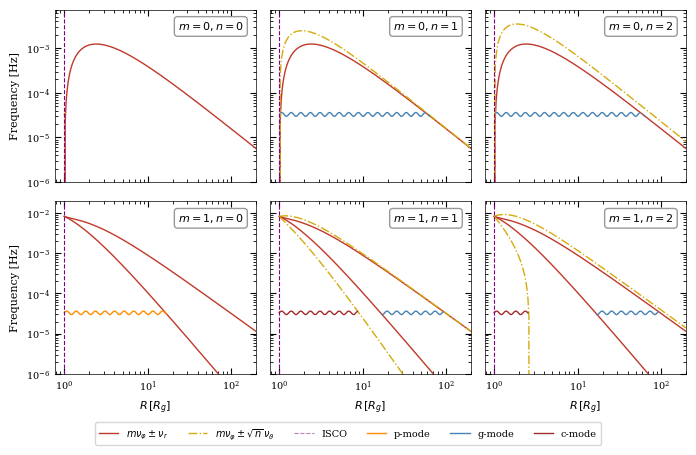

In [60]:
# ── frequencies on the grid (computed once outside the plot loop) ────
Omega      = nu_phi(RIVR, A)    # azimuthal orbital frequency
Omega_perp = nu_theta(RIVR, A)  # vertical epicyclic frequency
kappa      = nu_r(RIVR, A)      # radial epicyclic frequency

# ── choose spin slice ────────────────────────────────────────────────
ia = 200   # index into spin axis  (ia=0 → a ≈ -0.99)
a_val      = A[0, 0, ia, 0]
r_isco_val = r_isco(a_val)

NM, NJ = 2, 3   # m = 0..3,  n = 0..2

fig, axes = plt.subplots(NM, NJ, figsize=(7, 4.5), sharex=True)

legend_handles = {}   # filled in-place by plot_target_wavy_trapped

for im in range(NM):
    for ij in range(NJ):
        ax = axes[im, ij]
        fix_spines(ax)

        mm = int(round(m[im, ij, ia, 0]))
        nn = int(round(j[im, ij, ia, 0]))   # renamed j → n

        # boundary curves
        m_Omega         = mm * Omega[im, ij, ia, :]
        freq_plus_kappa = m_Omega + kappa[im, ij, ia, :]
        freq_plus_n20   = m_Omega + Omega_perp[im, ij, ia, :] * np.sqrt(nn)
        if mm > 0:
            freq_minus_kappa = m_Omega - kappa[im, ij, ia, :]
            freq_minus_n20   = m_Omega - Omega_perp[im, ij, ia, :] * np.sqrt(nn)
        else:
            freq_minus_kappa = freq_plus_kappa
            freq_minus_n20   = freq_plus_n20

        all_frequencies = [m_Omega, freq_plus_kappa, freq_minus_kappa,
                           freq_plus_n20, freq_minus_n20]
        has_negative = any(np.any(f < 0) for f in all_frequencies)

        r_vals = RIVR[im, ij, ia, :]

        # ── draw boundary curves ─────────────────────────────────────
        plots_frq(ax, r_vals, all_frequencies, mm, nn)

        # ── target band + wavy line (trapped modes only) ─────────────
        #ax.fill_between(r_vals, TARGET_MIN, TARGET_MAX, color='gray', alpha=0.2)
        plot_target_wavy_trapped(ax, r_vals, freq_plus_kappa, freq_minus_kappa,
                                 freq_plus_n20, freq_minus_n20, NU0, mm, nn,
                                 legend_handles)

        # ── ISCO vertical line ───────────────────────────────────────
        ax.axvline(r_isco_val, color='purple', linestyle='--', linewidth=0.8)

        # ── scale ────────────────────────────────────────────────────
        #ax.set_ylim(bottom=1e-5)
        #ax.set_yscale("symlog", linthresh=1e-5) if has_negative else ax.set_yscale("log")
        ax.set_xscale("log")
        ax.set_xlim(right=np.max(RIVR))

        # ── internal title ───────────────────────────────────────────
        ax.text(0.94, 0.94, fr"$m = {mm},  n = {nn}$",
                transform=ax.transAxes, #fontweight='bold',
                ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='gray', alpha=0.8))

        # ── axis labels only on borders ──────────────────────────────
        if im == NM - 1:
            ax.set_xlabel(r"$R\,[R_g]$")
        else:
            ax.tick_params(labelbottom=False)

        if ij == 0:
            ax.set_ylabel("Frequency [Hz]")
        else:
            ax.tick_params(labelleft=False)

for im in range(NM):
    row_axes = [axes[im, ij] for ij in range(NJ)]
    row_tops = [ax.get_ylim()[1] for ax in row_axes]
    global_top = max(row_tops)
    for ax in row_axes:
        ax.set_ylim(bottom=1e-6, top=global_top*2)
        ax.set_yscale("log")

# ── single shared legend ─────────────────────────────────────────────
h_red   = mlines.Line2D([], [], color='#C0392B', lw=1, ls='-',
                         label=r'$m\nu_\varphi \pm \nu_r$')
h_green = mlines.Line2D([], [], color='#D4AC0D', lw=1, ls='-.',
                         label=r'$m\nu_\varphi \pm \sqrt{n}\,\nu_\vartheta$')
h_black = mlines.Line2D([], [], color='black', lw=1, ls=':',
                         label=r'$m\nu_\varphi$')
#h_gray  = mpatches.Patch(facecolor='gray', alpha=0.3, label='Target range')
h_isco  = mlines.Line2D([], [], color='purple', lw=0.8, ls='--', alpha=0.5,
                         label='ISCO')

static  = [h_red, h_green, h_isco]
dynamic = list(legend_handles.values())   # g-mode, c-mode, p-mode (appear as needed)

fig.legend(
    handles=static + dynamic,
    loc='lower center',
    ncol=len(static + dynamic),
    frameon=True,
    bbox_to_anchor=(0.5, -0.01)
)

plt.tight_layout(rect=[0, 0.04, 1, 0.995])
plt.savefig('cmodes_plots/regioni.pdf', bbox_inches='tight')
plt.show()

### second

In [56]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ── grid (higher resolution in a for smoother scatter/heatmap) ─────────
params = {
    "m":    (0, 2, 3),
    "j":    (0, 2, 3),       # n = 0, 1, 2
    "a":    (-1, 1, 120),
    "rivr": (1, 500, 400)
}
pv, ma = create_param_grid(params)
m_g, j_g, A, RIVR = ma
RIVR = np.maximum(RIVR, r_isco(A))

Om  = nu_phi(RIVR, A)       # Ω_φ
Op  = nu_theta(RIVR, A)     # Ω_θ
Kp  = nu_r(RIVR, A)         # κ

NM, NJ, NA, NR = m_g.shape
a_vec = A[0, 0, :, 0]       # 1-D spin vector
r_vec = RIVR[0, 0, 0, :]    # 1-D radius vector (at a fixed a; used only for ref)

# colour / marker coding for mode types
MODE_STYLE = {
    'g': dict(color='steelblue',    marker='o', label='g-mode'),
    'c': dict(color='brown', marker='s', label='c-mode'),
    'p': dict(color='darkorange',   marker='^', label='p-mode'),
}

# spin values used for the overlaid propagation diagram (view 3)
SPIN_OVERLAY = [-0.99, -0.5, 0.0, 0.5, 0.99]
SPIN_COLORS  = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

print(f"Grid shape: {m_g.shape}  (m, n, a, r)")

Grid shape: (3, 3, 120, 400)  (m, n, a, r)


In [57]:
def mode_regions(im, ij, tol_frac=0):
    """
    Return boolean arrays (NA, NR) for g, c, p regions.
    'Match' means: target frequency falls inside the region.
    tol_frac: fractional half-width around NU0 treated as a match band.
    """
    mm = int(round(m_g[im, ij, 0, 0]))
    nn = int(round(j_g[im, ij, 0, 0]))

    lo, hi = NU0 * (1 - tol_frac), NU0 * (1 + tol_frac)

    mO  = mm * Om[im, ij, :, :]          # (NA, NR)
    fpk = mO + Kp[im, ij, :, :]
    fpn = mO + Op[im, ij, :, :] * np.sqrt(nn)
    if mm > 0:
        fmk = mO - Kp[im, ij, :, :]
        fmn = mO - Op[im, ij, :, :] * np.sqrt(nn)
    else:
        fmk = fpk
        fmn = fpn

    if nn == 0:
        if mm == 0:
            kappa_1d = Kp[im, ij, :, :]
            kappa_max = np.nanmax(kappa_1d, axis=-1, keepdims=True)
            r_max_idx = np.nanargmax(kappa_1d, axis=-1)
            ia_idx = np.arange(kappa_1d.shape[0])
            r_max = RIVR[im, ij, ia_idx, r_max_idx]
            r_max = r_max[:, None]
            R_grid = RIVR[im, ij, :, :]
            p = (NU0 <= kappa_max) & (NU0 >= kappa_1d) & ~np.isnan(fpk) & (R_grid < r_max)
        else:
            p = (NU0 <= fmk) & ~np.isnan(fpk)
        c = np.zeros_like(p, dtype=bool)
        g = np.zeros_like(p, dtype=bool)

    elif mm == 0:
        kappa_2d = Kp[im, ij, :, :]
        g = (NU0 <= kappa_2d) & ~np.isnan(kappa_2d)
        c = np.zeros((NA, NR), dtype=bool)
        p = np.zeros((NA, NR), dtype=bool)

    else:
        g = (NU0 >= fmk) & (NU0 <= fpk) & ~np.isnan(fmk) & ~np.isnan(fpk)
        c = (NU0 <= fmn) & (fmn > 0) & ~np.isnan(fmn) & (NU0 > 0)
        p = np.zeros_like(g, dtype=bool)

    # remove g/c overlap with p
    g = g & ~p
    c = c & ~g & ~p

    return g, c, p, mm, nn


def find_continuous_segments(mask):
    segs = []; in_seg = False
    for i, v in enumerate(mask):
        if v and not in_seg:  start = i; in_seg = True
        elif not v and in_seg: segs.append((start, i-1)); in_seg = False
    if in_seg: segs.append((start, len(mask)-1))
    return segs


# ── resonance radius helpers ────────────────────────────────────────────
def r_ivr(a, nu_obs=NU0, m=1, n=1, M=M_BH, n_scan=8000):
    """
    Vertical resonance radius: ω̃ - sqrt(n)·Ω_z = 0
    i.e.  m·Ω_φ(r) - sqrt(n)·Ω_θ(r) = nu_obs
    Sign convention same as ILR/OLR.
    """
    a = float(a)
    isco = float(r_isco(a))
    r = np.geomspace(isco * 1.001, 5000.0, n_scan)

    om_tilde = 2*np.pi*nu_obs - m * 2*np.pi * nu_phi(r, a, M)
    oz       = 2*np.pi * nu_theta(r, a, M)

    # IVR: om_tilde + sqrt(n)*oz = 0
    diff = om_tilde + np.sqrt(n) * oz
    sign_changes = np.where(np.diff(np.sign(diff)) != 0)[0]
    if len(sign_changes) == 0:
        return np.nan
    i = sign_changes[0]
    denom = diff[i+1] - diff[i]
    if denom == 0:
        return float(r[i])
    return float(r[i] - diff[i] * (r[i+1] - r[i]) / denom)


def resonance_curves(a_arr, nu_obs=NU0, m=1, n=1, M=M_BH):
    """Vectorised: return (r_ILR, r_OLR, r_IVR) arrays over a_arr."""
    r_ilr_arr = np.array([r_ilr(a, nu_obs, m, M) for a in a_arr])
    r_olr_arr = np.array([r_olr(a, nu_obs, m, M) for a in a_arr])
    r_ivr_arr = np.array([r_ivr(a, nu_obs, m, n, M) for a in a_arr])
    return r_ilr_arr, r_olr_arr, r_ivr_arr

/tmp/ipykernel_7855/995595641.py:65: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  p_none = mpatches.Patch(color='#F5F5F0', edgecolor='#999', label='no match')
/tmp/ipykernel_7855/995595641.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.995])


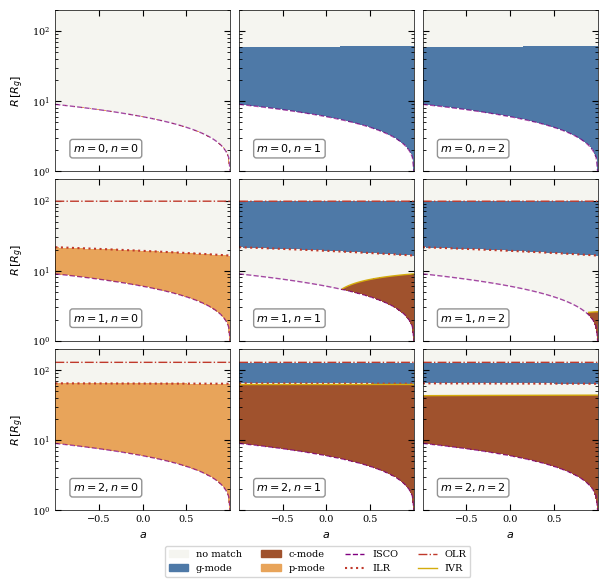

In [58]:
# encode mode type as integer: 0=none, 1=g, 2=c, 3=p
CMAP_DISCRETE = mcolors.ListedColormap(['#F5F5F0', '#4E79A7', '#A0522D', '#E8A45A'])
BOUNDS = [-0.5, 0.5, 1.5, 2.5, 3.5]
NORM   = mcolors.BoundaryNorm(BOUNDS, CMAP_DISCRETE.N)

# coarser spin grid for resonance root-finding (one set per panel)
a_res = np.linspace(-0.998, 0.998, 60)

fig, axes = plt.subplots(NM, NJ, figsize=(7, 6.5), sharex=True, sharey=True,
                        gridspec_kw={"wspace": 0.05, "hspace": 0.05})

for im in range(NM):
    for ij in range(NJ):
        ax = axes[im, ij]
        fix_spines(ax)
        g, c, p, mm, nn = mode_regions(im, ij)

        code = np.zeros((NA, NR), dtype=float)
        code[g] = 1
        code[c] = 2
        code[p] = 3

        R_grid    = RIVR[im, ij, :, :]
        A_grid    = A[im, ij, :, :]
        isco_grid = r_isco(A_grid)
        code[R_grid < isco_grid] = np.nan

        ax.pcolormesh(
            A_grid, R_grid, code,
            cmap=CMAP_DISCRETE, norm=NORM,
            shading='auto', rasterized=True
        )

        # ISCO line
        ax.plot(a_vec, r_isco(a_vec), color='purple', ls='--', lw=1, alpha=0.7)

        # resonance curves — computed for this panel's (mm, nn)
        # ILR/OLR depend on m; IVR depends on m and n
        # skip degenerate m=0 case (no meaningful Lindblad resonances)
        if mm > 0:
            ilr_c, olr_c, ivr_c = resonance_curves(a_res, m=mm, n=max(nn, 1))
            ax.plot(a_res, ilr_c, color='#C0392B', lw=1.5, ls=':')
            ax.plot(a_res, olr_c, color='#C0392B', lw=1, ls='-.')
            if nn > 0:
                ax.plot(a_res, ivr_c, color='#D4AC0D', lw=1, ls='-')

        ax.set_yscale('log')
        ax.set_xlim(-1, 1)
        ax.set_ylim(1, 2e2)
        ax.grid(False)
        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=4, prune='both'))

        ax.text(0.1, 0.1, fr"$m={mm}, n={nn}$",
                #fontweight='bold',
                transform=ax.transAxes,
                ha='left', va='bottom',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.85))

        if im == NM-1: ax.set_xlabel(r"$a$")
        else:          ax.tick_params(labelbottom=False)
        if ij == 0:    ax.set_ylabel(r"$R\,[R_g]$")
        else:          ax.tick_params(labelleft=False)

# shared legend
p_none = mpatches.Patch(color='#F5F5F0', edgecolor='#999', label='no match')
p_g    = mpatches.Patch(color='#4E79A7', label='g-mode')
p_c    = mpatches.Patch(color='#A0522D', label='c-mode')
p_p    = mpatches.Patch(color='#E8A45A', label='p-mode')
h_i    = mlines.Line2D([],[],color='purple',   ls='--', lw=1, label='ISCO')
h_ilr  = mlines.Line2D([],[],color='#C0392B', ls=':',  lw=1.5, label='ILR')
h_olr  = mlines.Line2D([],[],color='#C0392B', ls='-.', lw=1, label='OLR')
h_ivr  = mlines.Line2D([],[],color='#D4AC0D', ls='-',  lw=1, label='IVR')
fig.legend(handles=[p_none, p_g, p_c, p_p, h_i, h_ilr, h_olr, h_ivr],
           loc='lower center', ncol=4, frameon=True,
           bbox_to_anchor=(0.5, -0.))

plt.tight_layout(rect=[0, 0.05, 1, 0.995])
plt.savefig('cmodes_plots/heatmap_rg.pdf', bbox_inches='tight')
plt.show()